# Alzheimer's Disease Classification — Results

This notebook runs all four models and displays their results in one place.
Each model classifies subjects as **Cognitively Normal (CN)** vs **Alzheimer's Disease (AD)**
using PET imaging biomarkers from the [ADNI](https://adni.loni.usc.edu/) dataset.

**Evaluation:** All models use a stratified 80/20 train/test split. The training portion
is evaluated with 5-fold cross-validation (CV AUC mean ± std) to give a reliable estimate
of generalization. Final metrics are reported on the held-out test set.

**Models:**
1. Logistic Regression + Random Forest on amyloid, tau, and combined ROI features
2. Feedforward Neural Network (3-layer MLP) on combined ROI features
3. Longitudinal Tau Regression — baseline + accumulation slope features
4. 2D CNN on raw tau PET image slices

In [6]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from IPython.display import display

RESULTS_DIR = Path("results")
PLOTS_DIR   = RESULTS_DIR / "plots"

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

## Run all models

This cell trains and evaluates every model, saving plots to `results/plots/`
and metrics to `results/metrics.json`. Runtime is dominated by the Neural Network
(cross-validation × 5 folds). The CNN cell is optional and much slower.

In [7]:
from LogisticRegression.model import model as run_logreg
from NeuralNet.neural_network import model as run_nn
from LongitudinalTauBC.model import model as run_longitudinal

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

all_results = {}
all_results.update(run_logreg())
all_results.update(run_nn())
all_results.update(run_longitudinal())

with open(RESULTS_DIR / "metrics.json", "w") as f:
    json.dump(all_results, f, indent=2)

print("All models complete. Results saved to results/metrics.json")


Results for amyloid dataset:
  LogisticRegression: CV AUC=0.8252 ± 0.0840 | Test Accuracy=0.9600 | Test AUC=0.9815
  Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98        63
           1       0.85      0.92      0.88        12

    accuracy                           0.96        75
   macro avg       0.92      0.94      0.93        75
weighted avg       0.96      0.96      0.96        75

  RandomForest: CV AUC=0.8372 ± 0.0811 | Test Accuracy=0.9200 | Test AUC=0.9656
  Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.95        63
           1       0.71      0.83      0.77        12

    accuracy                           0.92        75
   macro avg       0.84      0.88      0.86        75
weighted avg       0.93      0.92      0.92        75


Results for tau dataset:
  LogisticRegression: CV AUC=0.8951 ± 0.0766 | Test Accuracy=0.9600 | Test

## Summary Table

In [8]:
rows = []
for section, section_data in all_results.items():
    if not isinstance(section_data, dict):
        continue
    for model_name, metrics in section_data.items():
        if not isinstance(metrics, dict) or "cv_auc_mean" not in metrics:
            continue
        rows.append({
            "Model":        model_name,
            "Feature Set":  metrics.get("feature_set", ""),
            "CV AUC":       f"{metrics['cv_auc_mean']:.4f} ± {metrics['cv_auc_std']:.4f}",
            "Test AUC":     f"{metrics['test_auc']:.4f}",
            "Test Accuracy":f"{metrics['test_accuracy']:.4f}",
        })

summary_df = pd.DataFrame(rows)
display(summary_df.style.set_caption("Model Comparison — All Feature Sets"))

,Model,Feature Set,CV AUC,Test AUC,Test Accuracy
0,LogisticRegression,amyloid,0.8252 ± 0.0840,0.9815,0.9600
1,RandomForest,amyloid,0.8372 ± 0.0811,0.9656,0.9200
2,LogisticRegression,tau,0.8951 ± 0.0766,0.9921,0.9600
3,RandomForest,tau,0.8625 ± 0.0699,0.9868,0.9733
4,LogisticRegression,combined,0.8920 ± 0.0606,1.0000,0.9867
5,RandomForest,combined,0.8642 ± 0.0708,0.9802,0.9467
6,Baseline tau,Baseline tau,0.7970 ± 0.1668,0.8750,0.8125
7,Tau slope,Tau slope,0.6978 ± 0.1764,0.7083,0.8125
8,Baseline + slope,Baseline + slope,0.8141 ± 0.1276,0.8542,0.8125


## Logistic Regression Feature Importance

Coefficients from the logistic regression models show which brain regions are most
predictive of AD. Positive coefficients (red) indicate higher SUVR → more likely AD;
negative (blue) indicate protective or inversely correlated regions.

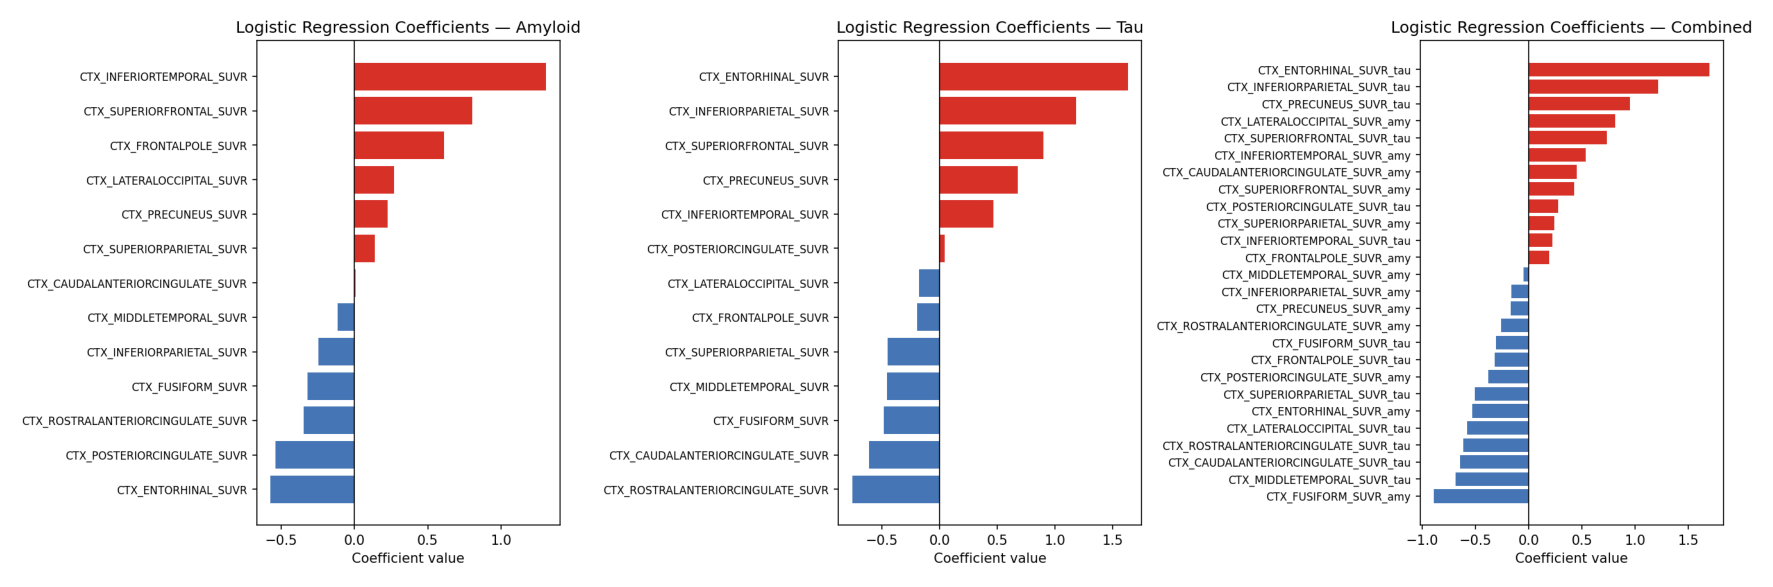

In [9]:
img_path = PLOTS_DIR / "logreg_feature_importance.png"
if img_path.exists():
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.imshow(mpimg.imread(img_path))
    ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Plot not found — run the models cell above first.")

## Neural Network Training Curve

The red dashed line marks where early stopping triggered. Validation loss diverging
from training loss would indicate overfitting — dropout and L2 regularization keep them close.

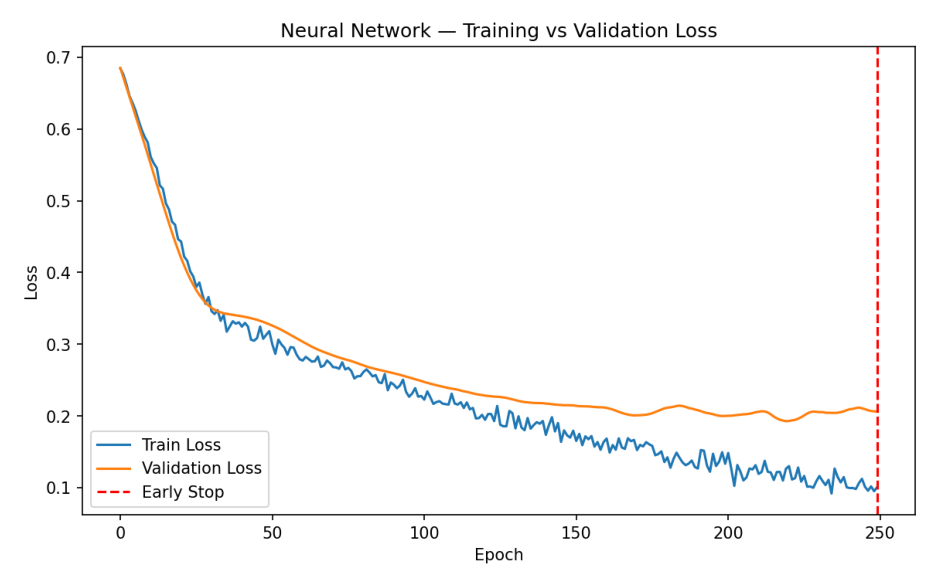

In [10]:
img_path = PLOTS_DIR / "nn_training_curve.png"
if img_path.exists():
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.imshow(mpimg.imread(img_path))
    ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Plot not found — run the models cell above first.")

## 2D CNN (Optional)

This cell runs the convolutional network on raw PET image slices.
It requires the NIfTI files under `data/Tau_PET_Images/nifti_output_with_RID/`
and takes significantly longer to run than the tabular models.

In [11]:
import sys
sys.path.insert(0, "2D-CNN")

from cnn import main as run_cnn
run_cnn()

Epoch 1, Loss: 0.2958
Epoch 2, Loss: 0.2012
Epoch 3, Loss: 0.1600
Epoch 4, Loss: 0.1435
Epoch 5, Loss: 0.1125
Epoch 6, Loss: 0.0907
Epoch 7, Loss: 0.0775
Epoch 8, Loss: 0.0622
Epoch 9, Loss: 0.0490
Epoch 10, Loss: 0.0383
Epoch 11, Loss: 0.0344
Epoch 12, Loss: 0.0228
Epoch 13, Loss: 0.0159
Epoch 14, Loss: 0.0167
Epoch 15, Loss: 0.0121
Slice-level test accuracy: 0.8235
